In [17]:
import datetime
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from aquahawk import load_aquahawk_data
from rachio import load_rachio_data
df = load_aquahawk_data()
df['Timestamp'] = pd.to_datetime(df['Timestamp'], utc=True)
# Aquahawk data appears to be cumalative, e.g. a reading at 5 AM records the water used between 4 AM and 5 AM
# To account for this, offset by 1 hour
df['Timestamp'] = df['Timestamp'] - pd.Timedelta(hours=1)
dfi = pd.DatetimeIndex(df.Timestamp)
df['Month'] = dfi.month
df['Hour'] = dfi.hour
df['Day'] = dfi.day
df['WeekDay'] = dfi.dayofweek
df["Year"] = dfi.year


# Now load Rachio data
rd = load_rachio_data()

rd['Timestamp'] = pd.to_datetime(rd['Timestamp'], utc=True)

# The Rachio started on 7/10/2023
# Aquahawk was disabled until 5/18/2023
# so subset both to the rachio start date
start_date = datetime.datetime(2023, 7, 10)
# Define the timezone offset (e.g., -07:00)
offset = datetime.timezone(datetime.timedelta(hours=-7))
# Create the datetime object with the timezone
start_date = start_date.replace(tzinfo=offset)
df = df[df.Timestamp > start_date]
rd = rd[rd.Timestamp > start_date]
# Create a category with the remaining real "zones"
rd["Zone"] = rd["Zone"].astype("category")

# Pivot df2 to have 'zone' categories as columns, 0 if the zone isn't present then
rd_pivot = rd.pivot_table(index=['Year', 'Month', 'Day', 'Hour'], columns='Zone', values='WateringMinutes', fill_value=0).reset_index()
rd_pivot.sort_values(by=['Year', 'Month', 'Day', 'Hour'], ascending=True, inplace=True)
# Subset all the aquahawk data down
dfw = df.loc[:,['Year', 'Month', 'Day', 'Hour', 'Timestamp','Water Use (Gallons)', 'WeekDay']]
dfw.sort_values(by=['Year', 'Month', 'Day', 'Hour'], ascending=True, inplace=True)

# Now merge the two datasets and fill in any missing values with NA
ad = pd.merge(dfw, rd_pivot, how="left")
ad.sort_values(by=['Year', 'Month', 'Day', 'Hour'], ascending=True, inplace=True)
ad.fillna(0, inplace=True)
# Output temporary analysis files
ad.to_csv("/Users/nigel/git/watermon/combined_usage.csv")

Genereate Intervals of length 126
Result of login was <Response [200]>, and that is True
File: /Users/nigel/git/watermon/data/aquahawk_weeklies/AquaHawk_TimeSeriesReport_2021-12-27T08.csv already exists, not performing query
File: /Users/nigel/git/watermon/data/aquahawk_weeklies/AquaHawk_TimeSeriesReport_2022-01-03T08.csv already exists, not performing query
File: /Users/nigel/git/watermon/data/aquahawk_weeklies/AquaHawk_TimeSeriesReport_2022-01-10T08.csv already exists, not performing query
File: /Users/nigel/git/watermon/data/aquahawk_weeklies/AquaHawk_TimeSeriesReport_2022-01-17T08.csv already exists, not performing query
File: /Users/nigel/git/watermon/data/aquahawk_weeklies/AquaHawk_TimeSeriesReport_2022-01-24T08.csv already exists, not performing query
File: /Users/nigel/git/watermon/data/aquahawk_weeklies/AquaHawk_TimeSeriesReport_2022-01-31T08.csv already exists, not performing query
File: /Users/nigel/git/watermon/data/aquahawk_weeklies/AquaHawk_TimeSeriesReport_2022-02-07T08.

In [13]:
print(rd)
print(df)

    Year  Month  Day  WeekDay  Hour  WateringMinutes              Zone  \
1   2023      7   10        0     1        26.566667        Front Yard   
2   2023      7   10        0     2        23.433333        Front Yard   
3   2023      7   11        1     1        25.566667        Front Yard   
4   2023      7   11        1     2        24.433333        Front Yard   
5   2023      7   15        5    20        28.983333        Front Yard   
..   ...    ...  ...      ...   ...              ...               ...   
76  2024      5   10        4    20        43.633333  Backyard Orchard   
77  2024      5   10        4    21        60.000000  Backyard Orchard   
78  2024      5   10        4    22        60.000000  Backyard Orchard   
79  2024      5   10        4    23        60.000000  Backyard Orchard   
80  2024      5   11        5     0        16.700000  Backyard Orchard   

                   Timestamp  
1  2023-07-10 08:33:26+00:00  
2  2023-07-10 09:00:00+00:00  
3  2023-07-11 08:3

In [3]:
print(df)

          Account     Meter     Radio                  Name  \
504    324295-518  18928959  71578986  DELANEY  NIGEL EMILY   
505    324295-518  18928959  71578986  DELANEY  NIGEL EMILY   
506    324295-518  18928959  71578986  DELANEY  NIGEL EMILY   
507    324295-518  18928959  71578986  DELANEY  NIGEL EMILY   
508    324295-518  18928959  71578986  DELANEY  NIGEL EMILY   
...           ...       ...       ...                   ...   
20827  324295-518  18928959  71578986  DELANEY  NIGEL EMILY   
20828  324295-518  18928959  71578986  DELANEY  NIGEL EMILY   
20829  324295-518  18928959  71578986  DELANEY  NIGEL EMILY   
20830  324295-518  18928959  71578986  DELANEY  NIGEL EMILY   
20831  324295-518  18928959  71578986  DELANEY  NIGEL EMILY   

                 Address   City State    Zip Last Day Reported  \
504    910 EUREKA AVENUE  DAVIS    CA  95616  2024-02-04 03:00   
505    910 EUREKA AVENUE  DAVIS    CA  95616  2024-02-04 03:00   
506    910 EUREKA AVENUE  DAVIS    CA  95616 

In [2]:
print(rd)

    Year  Month  Day  WeekDay  Hour  WateringMinutes              Zone  \
1   2023      7   10        0     1        26.566667        Front Yard   
2   2023      7   10        0     2        23.433333        Front Yard   
3   2023      7   11        1     1        25.566667        Front Yard   
4   2023      7   11        1     2        24.433333        Front Yard   
5   2023      7   15        5    20        28.983333        Front Yard   
..   ...    ...  ...      ...   ...              ...               ...   
76  2024      5   10        4    20        43.633333  Backyard Orchard   
77  2024      5   10        4    21        60.000000  Backyard Orchard   
78  2024      5   10        4    22        60.000000  Backyard Orchard   
79  2024      5   10        4    23        60.000000  Backyard Orchard   
80  2024      5   11        5     0        16.700000  Backyard Orchard   

                   Timestamp  
1  2023-07-10 08:33:26+00:00  
2  2023-07-10 09:00:00+00:00  
3  2023-07-11 08:3

In [16]:
print(df.loc[df.shape[0]])

Account                               324295-518
Meter                                   18928959
Radio                                   71578986
Name                        DELANEY  NIGEL EMILY
Address                        910 EUREKA AVENUE
City                                       DAVIS
State                                         CA
Zip                                        95616
Last Day Reported               2023-12-24 03:00
Timestamp              2023-11-19 17:00:00+00:00
Water Use (CF)                              0.24
Water Use (Gallons)                          1.8
Water Reading                           86016.64
Month                                         11
Hour                                          17
Day                                            6
Year                                        2023
Name: 7553, dtype: object


In [6]:

print(dfw)
print(rd_pivot)

      Year  Month  Day  Hour                 Timestamp  Water Use (Gallons)
9415  2023      7   10     8 2023-07-10 08:00:00+00:00                 4.11
9416  2023      7   10     9 2023-07-10 09:00:00+00:00                 0.00
9417  2023      7   10    10 2023-07-10 10:00:00+00:00                20.95
9418  2023      7   10    11 2023-07-10 11:00:00+00:00                 0.00
9419  2023      7   10    12 2023-07-10 12:00:00+00:00                 1.20
...    ...    ...  ...   ...                       ...                  ...
6883  2024      5   19    20 2024-05-19 20:00:00+00:00                11.52
6884  2024      5   19    21 2024-05-19 21:00:00+00:00                69.42
6885  2024      5   19    22 2024-05-19 22:00:00+00:00                 0.45
6886  2024      5   19    23 2024-05-19 23:00:00+00:00                 1.50
6887  2024      5   20     0 2024-05-20 00:00:00+00:00                 0.00

[7553 rows x 6 columns]
Zone  Year  Month  Day  WeekDay  Hour  Backyard Bubblers  Backy

      Year  Month  Day  Hour                 Timestamp  Water Use (Gallons)  \
0     2023      7   10     8 2023-07-10 08:00:00+00:00                 4.11   
1     2023      7   10     9 2023-07-10 09:00:00+00:00                 0.00   
2     2023      7   10    10 2023-07-10 10:00:00+00:00                20.95   
3     2023      7   10    11 2023-07-10 11:00:00+00:00                 0.00   
4     2023      7   10    12 2023-07-10 12:00:00+00:00                 1.20   
...    ...    ...  ...   ...                       ...                  ...   
7548  2024      5   19    20 2024-05-19 20:00:00+00:00                11.52   
7549  2024      5   19    21 2024-05-19 21:00:00+00:00                69.42   
7550  2024      5   19    22 2024-05-19 22:00:00+00:00                 0.45   
7551  2024      5   19    23 2024-05-19 23:00:00+00:00                 1.50   
7552  2024      5   20     0 2024-05-20 00:00:00+00:00                 0.00   

      WeekDay  Backyard Bubblers  Backyard East Law

In [12]:
print(df)


          Account     Meter     Radio                  Name  \
504    324295-518  18928959  71578986  DELANEY  NIGEL EMILY   
505    324295-518  18928959  71578986  DELANEY  NIGEL EMILY   
506    324295-518  18928959  71578986  DELANEY  NIGEL EMILY   
507    324295-518  18928959  71578986  DELANEY  NIGEL EMILY   
508    324295-518  18928959  71578986  DELANEY  NIGEL EMILY   
...           ...       ...       ...                   ...   
20827  324295-518  18928959  71578986  DELANEY  NIGEL EMILY   
20828  324295-518  18928959  71578986  DELANEY  NIGEL EMILY   
20829  324295-518  18928959  71578986  DELANEY  NIGEL EMILY   
20830  324295-518  18928959  71578986  DELANEY  NIGEL EMILY   
20831  324295-518  18928959  71578986  DELANEY  NIGEL EMILY   

                 Address   City State    Zip Last Day Reported  \
504    910 EUREKA AVENUE  DAVIS    CA  95616  2024-02-04 03:00   
505    910 EUREKA AVENUE  DAVIS    CA  95616  2024-02-04 03:00   
506    910 EUREKA AVENUE  DAVIS    CA  95616 

In [41]:
# Print the unique categories
unique_categories = rd['Zone'].cat.categories
print(unique_categories)

Index(['Backyard Bubblers', 'Backyard East Lawn', 'Backyard Middle West',
       'Backyard Northwest', 'Backyard Orchard', 'Backyard South West',
       'Front Yard', 'Front Yard Tree'],
      dtype='object')


In [ ]:

print(df.columns)
print(df.index)
#df.set_index('Timestamp', inplace=True)



In [3]:


#df.set_index('Timestamp', inplace=True)


          Account     Meter     Radio                  Name  \
504    324295-518  18928959  71578986  DELANEY  NIGEL EMILY   
505    324295-518  18928959  71578986  DELANEY  NIGEL EMILY   
506    324295-518  18928959  71578986  DELANEY  NIGEL EMILY   
507    324295-518  18928959  71578986  DELANEY  NIGEL EMILY   
508    324295-518  18928959  71578986  DELANEY  NIGEL EMILY   
...           ...       ...       ...                   ...   
20659  324295-518  18928959  71578986  DELANEY  NIGEL EMILY   
20660  324295-518  18928959  71578986  DELANEY  NIGEL EMILY   
20661  324295-518  18928959  71578986  DELANEY  NIGEL EMILY   
20662  324295-518  18928959  71578986  DELANEY  NIGEL EMILY   
20663  324295-518  18928959  71578986  DELANEY  NIGEL EMILY   

                 Address   City State    Zip Last Day Reported  \
504    910 EUREKA AVENUE  DAVIS    CA  95616  2024-02-04 03:00   
505    910 EUREKA AVENUE  DAVIS    CA  95616  2024-02-04 03:00   
506    910 EUREKA AVENUE  DAVIS    CA  95616 

In [4]:
monthly_data = df.groupby(['Month', 'Hour', 'Day'])['Water Use (Gallons)'].sum()
#monthly_data.plot(kind='bar', xlabel='Month', ylabel='Gallons', title='Gallons per Month')
#plt.show()
#monthly_data = df.groupby(['Hour', 'Month'])['Water Use (Gallons)'].sum()
#monthly_data.plot(kind='bar', xlabel='Hour', ylabel='Gallons', title='Gallons per Hour')
#plt.show()
print(type(monthly_data))
monthly_data = monthly_data.to_frame()
print(monthly_data.reset_index(inplace=True))
print(monthly_data.dtypes)
print(monthly_data[monthly_data.Hour==8])

<class 'pandas.core.series.Series'>
None
Month                    int32
Hour                     int32
Day                      int32
Water Use (Gallons)    float64
dtype: object
      Month  Hour  Day  Water Use (Gallons)
56        1     8    0                 6.73
57        1     8    1               114.82
58        1     8    2                16.53
59        1     8    3                13.92
60        1     8    4                37.03
...     ...   ...  ...                  ...
1906     12     8    2                 7.55
1907     12     8    3                12.78
1908     12     8    4               152.67
1909     12     8    5                16.24
1910     12     8    6                 7.78

[84 rows x 4 columns]


/Users/nigel/miniconda3/envs/webdev/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/nigel/miniconda3/envs/webdev/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/nigel/miniconda3/envs/webdev/lib/python3.9/site-packages/seaborn/_oldcore.py:1057: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_data = data.groupby(
/Users/nigel/miniconda3/envs/webdev/lib/python3.9/site-packages/seabo

<Figure size 1200x800 with 0 Axes>

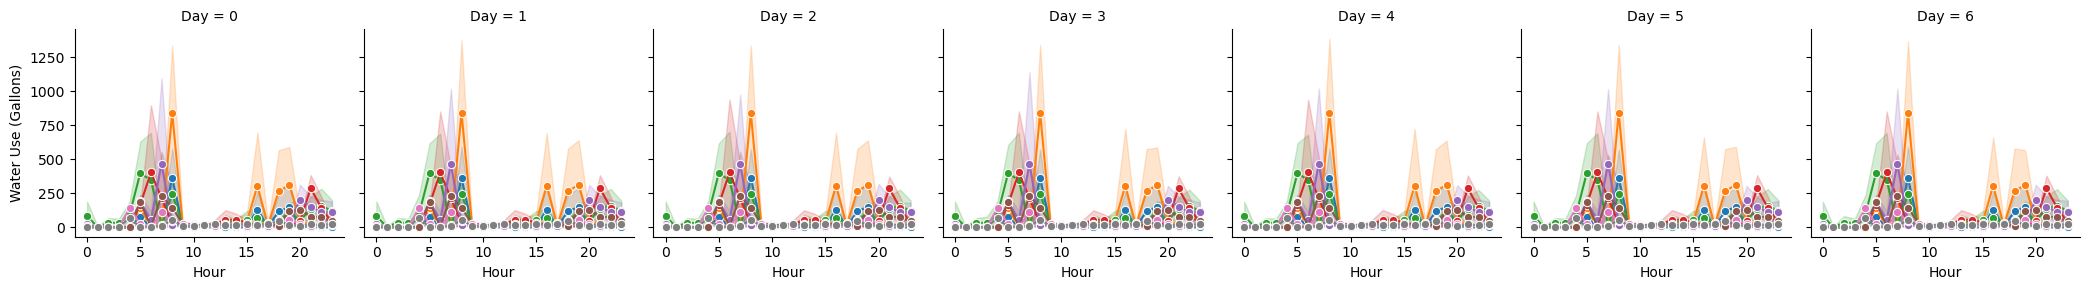

In [39]:
monthly_data['Month'] = monthly_data['Month'].astype('category')
monthly_data['Day'] = monthly_data['Day'].astype('category')
plt.figure(figsize=(12, 8))
g= sns.FacetGrid(monthly_data, col="Day")
g.map(sns.lineplot, x='Hour', y="Water Use (Gallons)", hue='Month', data=monthly_data, marker='o')
plt.show()

In [31]:
print(monthly_data[monthly_data.Month == 8])

     Month  Hour Day  Water Use (Gallons)
1799     8     0   1                 0.00
1800     8     0   2                 1.35
1801     8     0   3                 0.00
1802     8     0   4                 0.00
1803     8     0   5                 0.00
...    ...   ...  ..                  ...
2538     8    23  27                 2.62
2539     8    23  28                 1.94
2540     8    23  29                 4.71
2541     8    23  30                 2.02
2542     8    23  31                 4.56

[744 rows x 4 columns]


In [8]:

print(rd)
print(rd.dtypes)

     Year  Month  Day  WeekDay  Hour  WateringMinutes              Zone  \
0    2023      7    9        6    12         0.183333            Zone 1   
1    2023      7    9        6    12         0.766667            Zone 2   
2    2023      7    9        6    12         0.350000            Zone 3   
3    2023      7    9        6    12         0.283333            Zone 4   
4    2023      7    9        6    12         0.250000            Zone 5   
..    ...    ...  ...      ...   ...              ...               ...   
619  2024      5   10        4    20        43.633333  Backyard Orchard   
620  2024      5   10        4    21        60.000000  Backyard Orchard   
621  2024      5   10        4    22        60.000000  Backyard Orchard   
622  2024      5   10        4    23        60.000000  Backyard Orchard   
623  2024      5   11        5     0        16.700000  Backyard Orchard   

                     Timestamp  
0    2023-07-09 12:24:17-07:00  
1    2023-07-09 12:25:26-07:00  


Year                             int64
Month                            int64
Day                              int64
WeekDay                          int64
Hour                             int64
WateringMinutes                float64
Zone                            object
Timestamp          datetime64[ns, UTC]
dtype: object
     Year  Month  Day  WeekDay  Hour  WateringMinutes              Zone  \
0    2023      7    9        6    12         0.183333            Zone 1   
1    2023      7    9        6    12         0.766667            Zone 2   
2    2023      7    9        6    12         0.350000            Zone 3   
3    2023      7    9        6    12         0.283333            Zone 4   
4    2023      7    9        6    12         0.250000            Zone 5   
..    ...    ...  ...      ...   ...              ...               ...   
619  2024      5   10        4    20        43.633333  Backyard Orchard   
620  2024      5   10        4    21        60.000000  Backyard Orchard   

TypeError: Invalid comparison between dtype=datetime64[ns] and datetime